In [1]:
import causalchamber
from causalchamber.utils import graph_to_tikz
from causalchamber.ground_truth import latex_name
import sempler.plot


Citation
--------

If you use our datasets, simulators or Remote Lab for your work, please consider citing:

﻿@article{gamella2025chamber,
  author={Gamella, Juan L. and Peters, Jonas and B{"u}hlmann, Peter},
  title={Causal chambers as a real-world physical testbed for {AI} methodology},
  journal={Nature Machine Intelligence},
  doi={10.1038/s42256-024-00964-x},
  year={2025},
}


Support & feedback
------------------

If you encounter bugs o have feedback, please write us an email at

  support@causalchamber.ai

or leave an issue at

  https://github.com/juangamella/causal-chamber-package/issues

If you are a Remote Lab subscriber, contact us directly through any of
the provided support channels.



In [7]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join("..", "scr")))

%load_ext autoreload
%aimport TSCD, myutils, TSCD_nonlinear, generate_LSEM, metrics
%autoreload 1

from TSCD import TSCD as TSCD
from TSCD_nonlinear import TSCD_nonlinear_parallel

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [2]:
variables = ['red', 'green', 'blue',  'ir_1','vis_1', 'l_11', 'l_12', 'diode_vis_1', 't_vis_1']

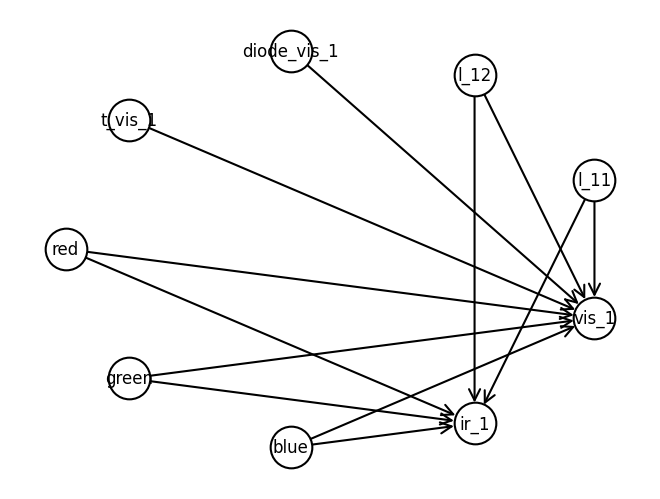

    \begin{tikzpicture}
        \node[circle, inner sep=0.12em] (0) at (-1.093, 1.302) {$R$};
        \node[circle, inner sep=0.12em] (1) at (-1.674, 0.295) {$G$};
        \node[circle, inner sep=0.12em] (2) at (-1.472, -0.850) {$B$};
        \node[circle, inner sep=0.12em] (3) at (-0.581, -1.597) {$\tilde{I}_1$};
        \node[circle, inner sep=0.12em] (4) at (0.581, -1.597) {$\tilde{V}_1$};
        \node[circle, inner sep=0.12em] (5) at (1.472, -0.850) {$L_{11}$};
        \node[circle, inner sep=0.12em] (6) at (1.674, 0.295) {$L_{12}$};
        \node[circle, inner sep=0.12em] (7) at (1.093, 1.302) {$D^V_1$};
        \node[circle, inner sep=0.12em] (8) at (0.000, 1.700) {$T^V_1$};
        \begin{scope}[]
            \draw[->] (0) edge (3);
            \draw[->] (0) edge (4);
            \draw[->] (1) edge (3);
            \draw[->] (1) edge (4);
            \draw[->] (2) edge (3);
            \draw[->] (2) edge (4);
            \draw[->] (5) edge (3);
            \draw[->] (5) edge (4

In [9]:
# Ground truth graph
true_dag = causalchamber.ground_truth.graph('lt', 'standard').loc[variables, variables].values
sempler.plot.plot_graph(true_dag, labels = variables)
print(graph_to_tikz(true_dag, radius=1.7, labels=[latex_name(v) for v in variables]))

In [3]:
from causalchamber.datasets import Dataset
dataset = Dataset(name="lt_interventions_standard_v1",root = 'data/')

experiments = [
    "uniform_reference",
    "uniform_red_strong",
    "uniform_green_strong",
    "uniform_blue_strong",
    "uniform_t_vis_1_strong",
    "uniform_l_11_mid",
    "uniform_l_12_mid",
    "uniform_diode_vis_1_mid",
]
observational_data = dataset.get_experiment(experiments[0]).as_pandas_dataframe()[variables].values
interventional_data = [dataset.get_experiment(e).as_pandas_dataframe()[variables].values for e in experiments]


Fetching list of available datasets from
  https://causalchamber.s3.eu-central-1.amazonaws.com/downloadables/directory.yaml ... done.
Dataset lt_interventions_standard_v1 found in "data/lt_interventions_standard_v1".


In [5]:
import numpy as np

# Map manipulable-name prefix in the experiment label -> observable variable
exp_to_var = {
    "uniform_reference":        None,       # observational
    "uniform_red_strong":       "red",
    "uniform_green_strong":     "green",
    "uniform_blue_strong":      "blue",
    "uniform_t_vis_1_strong":   "vis_1",
    "uniform_l_11_mid":         "l_11",
    "uniform_l_12_mid":         "l_12",
    "uniform_diode_vis_1_mid":  "vis_1",
}


var_idx = {v: i for i, v in enumerate(variables)}

# Binary intervention mask: I[e, j] = 1 iff experiment e intervenes on variables[j]
B = 1-np.zeros((len(experiments), len(variables)), dtype=int)
intervention_targets = []   # list[set[int]] — useful for many CD algorithms
for e, name in enumerate(experiments):
    v = exp_to_var[name]
    if v is None:
        intervention_targets.append(set())
    else:
        B[e, var_idx[v]] = 0
        intervention_targets.append({var_idx[v]})

B = B.T


X_list =  interventional_data

In [4]:
def precision(estimate, truth):
    # TP = edges in estimate that are also in truth
    # FP + TP = total edges in estimate
    return np.logical_and(estimate,truth).sum() / estimate.sum()

def recall(estimate, truth):
    # TP = edges in estimate that are also in truth
    # P = total edges in truth
    return np.logical_and(estimate,truth).sum() / truth.sum()

# TSCD

In [10]:
result_linear = TSCD(X_list, B)
est_dag_linear = (result_linear[0]!=0)
print("Precision for linear TSCD:", precision(est_dag_linear, true_dag.T))
print("Recall for linear TSCD:", recall(est_dag_linear, true_dag.T))

Precision for linear TSCD: 0.8571428571428571
Recall for linear TSCD: 0.5


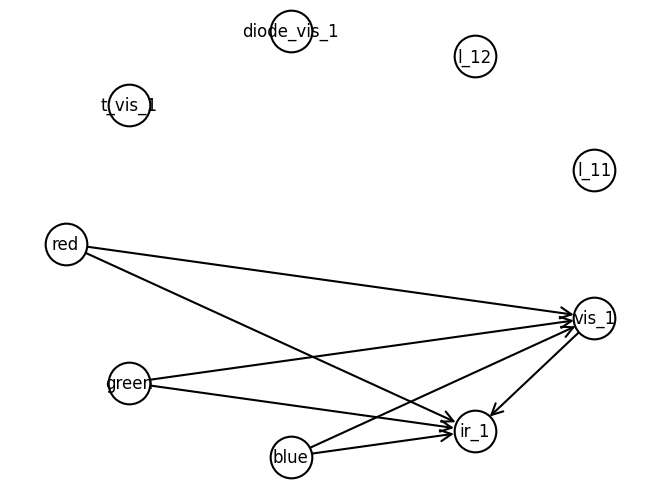

    \begin{tikzpicture}
        \node[circle, inner sep=0.12em] (0) at (-1.093, 1.302) {$R$};
        \node[circle, inner sep=0.12em] (1) at (-1.674, 0.295) {$G$};
        \node[circle, inner sep=0.12em] (2) at (-1.472, -0.850) {$B$};
        \node[circle, inner sep=0.12em] (3) at (-0.581, -1.597) {$\tilde{I}_1$};
        \node[circle, inner sep=0.12em] (4) at (0.581, -1.597) {$\tilde{V}_1$};
        \node[circle, inner sep=0.12em] (5) at (1.472, -0.850) {$L_{11}$};
        \node[circle, inner sep=0.12em] (6) at (1.674, 0.295) {$L_{12}$};
        \node[circle, inner sep=0.12em] (7) at (1.093, 1.302) {$D^V_1$};
        \node[circle, inner sep=0.12em] (8) at (0.000, 1.700) {$T^V_1$};
        \begin{scope}[]
            \draw[->] (0) edge (3);
            \draw[->] (0) edge (4);
            \draw[->] (1) edge (3);
            \draw[->] (1) edge (4);
            \draw[->] (2) edge (3);
            \draw[->] (2) edge (4);
            \draw[->] (4) edge (3);
        \end{scope}
    \end{tikz

In [15]:
sempler.plot.plot_graph(est_dag_linear.T, labels = variables)
print(graph_to_tikz(est_dag_linear.T, radius=1.7, labels=[latex_name(v) for v in variables]))

In [ ]:
result_nonlinear = TSCD_nonlinear_parallel(X_list, B, gate_threshold = 2)
print("Precision for nonlinear TSCD:", precision(result_nonlinear[1], true_dag.T))
print("Recall for nonlinear TSCD:", recall(result_nonlinear[1], true_dag.T))

Precision for nonlinear TSCD: 0.8
Recall for nonlinear TSCD: 1.0


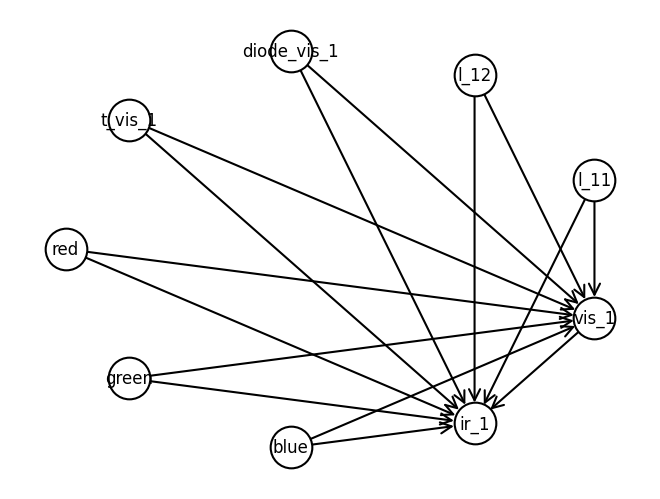

    \begin{tikzpicture}
        \node[circle, inner sep=0.12em] (0) at (-1.093, 1.302) {$R$};
        \node[circle, inner sep=0.12em] (1) at (-1.674, 0.295) {$G$};
        \node[circle, inner sep=0.12em] (2) at (-1.472, -0.850) {$B$};
        \node[circle, inner sep=0.12em] (3) at (-0.581, -1.597) {$\tilde{I}_1$};
        \node[circle, inner sep=0.12em] (4) at (0.581, -1.597) {$\tilde{V}_1$};
        \node[circle, inner sep=0.12em] (5) at (1.472, -0.850) {$L_{11}$};
        \node[circle, inner sep=0.12em] (6) at (1.674, 0.295) {$L_{12}$};
        \node[circle, inner sep=0.12em] (7) at (1.093, 1.302) {$D^V_1$};
        \node[circle, inner sep=0.12em] (8) at (0.000, 1.700) {$T^V_1$};
        \begin{scope}[]
            \draw[->] (0) edge (3);
            \draw[->] (0) edge (4);
            \draw[->] (1) edge (3);
            \draw[->] (1) edge (4);
            \draw[->] (2) edge (3);
            \draw[->] (2) edge (4);
            \draw[->] (4) edge (3);
            \draw[->] (5) edge (3

In [17]:
est_dag_nonlinear = (result_nonlinear[1]!=0)
sempler.plot.plot_graph(est_dag_nonlinear.T, labels = variables)
print(graph_to_tikz(est_dag_nonlinear.T, radius=1.7, labels=[latex_name(v) for v in variables]))

# Other methods

In [11]:
from other_algorithms.GES import GES
from other_algorithms.GIES import GIES
from other_algorithms.IGSP import IGSP
from other_algorithms.LinGAM import lingam_from_interventions, lingam_ica, lingam_direct
from other_algorithms.Notears_linear import notears_linear
from other_algorithms.PC import PC
from other_algorithms.sort_regress import SortRegress

In [12]:
# SortRegress

result_sort_regress = SortRegress(X_list[0])
print("Precision for SortRegress:", precision(result_sort_regress[0], true_dag.T))
print("Recall for SortRegress:", recall(result_sort_regress[0], true_dag.T))

Precision for SortRegress: 0.03821268411496902
Recall for SortRegress: 0.5


In [13]:
# add tiny noise to data == 0 to avoid numerical issues for LinGAM, IGSP and GIES
X_list_noisy = [X + 1e-5 * np.random.randn(*X.shape) for X in X_list]

In [14]:
# LinGAM

result_lingam_from_interventions_ica = lingam_from_interventions(X_list_noisy, B)

result_lingam_from_interventions_direct = lingam_from_interventions(X_list, B, lingam_method = "direct")

print("Precision for LinGAM (ICA):", precision(result_lingam_from_interventions_ica[0], true_dag.T))
print("Recall for LinGAM (ICA):", recall(result_lingam_from_interventions_ica[0], true_dag.T))

print("Precision for LinGAM (Direct):", precision(result_lingam_from_interventions_direct[0], true_dag.T))
print("Recall for LinGAM (Direct):", recall(result_lingam_from_interventions_direct[0], true_dag.T))

Precision for LinGAM (ICA): 0.028488453809406695
Recall for LinGAM (ICA): 0.5
Precision for LinGAM (Direct): 0.01897692500895326
Recall for LinGAM (Direct): 0.5


In [15]:
# GIES 
result_gies = GIES(X_list_noisy, B)
print("Precision for GIES:", precision(result_gies[0], true_dag))
print("Recall for GIES:", recall(result_gies[0], true_dag))

Precision for GIES: 0.8333333333333334
Recall for GIES: 0.4166666666666667


In [16]:
# IGSP 
result_igsp = IGSP(X_list_noisy, B)
print("Precision for IGSP:", precision(result_igsp[0], true_dag.T))
print("Recall for IGSP:", recall(result_igsp[0], true_dag.T))

Precision for IGSP: 0.00020875892932388382
Recall for IGSP: 0.16666666666666666
